In [1]:
import os

from linear_reg import history

os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = "0"
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BATCH_SIZE = 100

def load_image(img_path, size=(32, 32)):
    label = tf.constant(1, tf.int8) if tf.strings.regex_full_match(img_path, ".*automobile.*") else tf.constant(0, tf.int8)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, size) / 255.0
    return img, label

In [3]:
ds_train = tf.data.Dataset.list_files("data/cifar2/train/*/*.jpg")\
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE).shuffle(buffer_size=1000).batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

ds_test = tf.data.Dataset.list_files("data/cifar2/test/*/*.jpg")\
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

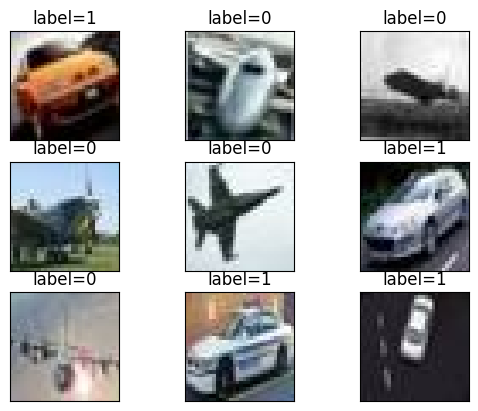

In [4]:
for i , (img, label) in enumerate(ds_train.unbatch().take(9)):
    ax = plt.subplot(3, 3, i + 1)
    ax.imshow(img.numpy())
    ax.set_title("label=%d" % label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [5]:
for x, y in ds_train.take(1):
    print(x.shape, y.shape)

(100, 32, 32, 3) (100,)


In [7]:
tf.keras.backend.clear_session()

inputs = layers.Input((32, 32, 3))
x = layers.Conv2D(32, kernel_size=(3, 3))(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(64, kernel_size=(5, 5))(x)
x = layers.MaxPool2D()(x)
x = layers.Dropout(rate=0.1)(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,425 (404.00 KB)

 Trainable params: 103,425 (404.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=['accuracy'])

history = model.fit(ds_train, epochs=10, validation_data=ds_test)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7948 - loss: 0.4290 - val_accuracy: 0.8655 - val_loss: 0.3228
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8702 - loss: 0.3052 - val_accuracy: 0.8830 - val_loss: 0.2778
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8943 - loss: 0.2592 - val_accuracy: 0.9110 - val_loss: 0.2193
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9132 - loss: 0.2161 - val_accuracy: 0.9190 - val_loss: 0.2020
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9243 - loss: 0.1936 - val_accuracy: 0.9280 - val_loss: 0.1832
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9337 - loss: 0.1683 - val_accuracy: 0.9280 - val_loss: 0.1792
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9403 - loss: 0.1484 - val_accuracy: 0.9335 - val_loss: 0.1716
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9479 - loss: 0.1300 - val_accu

In [10]:
def plot_metric(history, metric):
    train_metrics = history.history[metric]
    val_metrics = history.history['val_'+metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, 'bo--')
    plt.plot(epochs, val_metrics, 'ro-')
    plt.title('Training and validation '+ metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_"+metric, 'val_'+metric])
    plt.show()

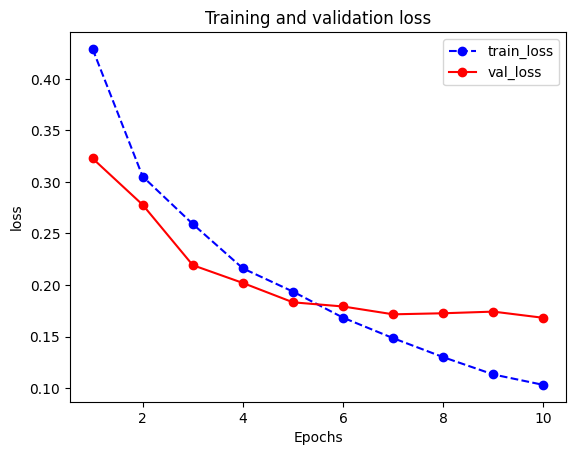

In [11]:
plot_metric(history,"loss")

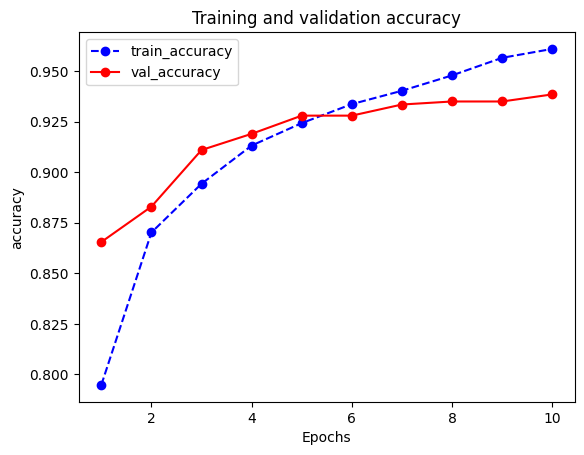

In [12]:
plot_metric(history,"accuracy")